# Importing Libraries 

In [1]:
import pandas as pd
import networkx as nx

In [2]:
df = pd.read_csv("relationships.csv") 
df.head()

,source,target,weight


In [3]:
df.columns, df.shape

(Index(['source', 'target', 'weight'], dtype='str'), (0, 3))

# Building the NetworkX graph object

In [5]:
G = nx.Graph()

print("nodes:", G.number_of_nodes())
print("edges:", G.number_of_edges())

nodes: 0
edges: 0


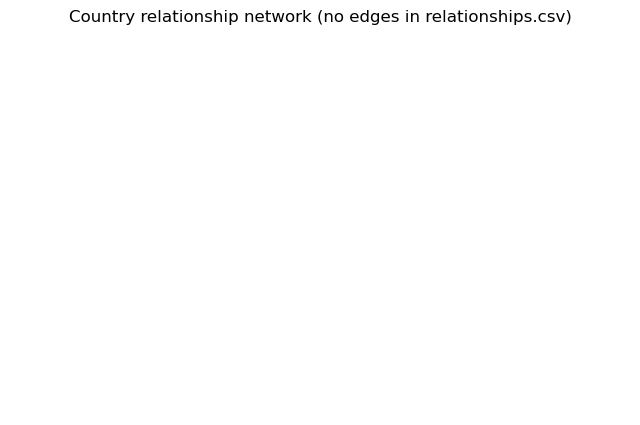

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.title("Country relationship network (no edges in relationships.csv)")
plt.axis("off")
plt.show()

# PyVis interactive graph

In [7]:
from pyvis.network import Network

net = Network(height="750px", width="100%", bgcolor="white", font_color="black")
net.barnes_hut()
net.from_nx(G)

html1 = "network_pyvis.html"
net.show(html1)
html1

'network_pyvis.html'

# Leiden communities

In [8]:
if G.number_of_edges() == 0:
    partition = None
    print("Leiden skipped: graph has 0 edges, so community detection is not meaningful.")
else:
    import igraph as ig
    import leidenalg

    nodes = list(G.nodes())
    idx = {n: i for i, n in enumerate(nodes)}
    edges = [(idx[a], idx[b]) for a, b in G.edges()]
    g_ig = ig.Graph(n=len(nodes), edges=edges, directed=False)
    g_ig.vs["name"] = nodes

    partition = leidenalg.find_partition(g_ig, leidenalg.ModularityVertexPartition)
    print("communities:", len(partition))

Leiden skipped: graph has 0 edges, so community detection is not meaningful.


# Community visualization 

In [9]:
net2 = Network(height="750px", width="100%", bgcolor="white", font_color="black")
net2.barnes_hut()
net2.from_nx(G)

html2 = "network_pyvis_leiden.html"
net2.show(html2)
html2

'network_pyvis_leiden.html'

# Comments
Community detection: 
The relationships dataset contains 0 rows, so the network has 0 edges. In this case, the Leiden algorithm cannot identify meaningful communities because there is no connectivity structure to partition. This suggests that, with the current entity extraction + filtering settings from Task 1.6, countries rarely co-occurred within the defined window, producing no country-to-country relationships.

# Centrality measures

In [10]:
if G.number_of_nodes() == 0:
    centrality_df = pd.DataFrame(columns=["degree", "closeness", "betweenness"])
    print("Centrality skipped: graph has 0 nodes.")
else:
    deg = nx.degree_centrality(G)
    clo = nx.closeness_centrality(G)
    bet = nx.betweenness_centrality(G)

    centrality_df = pd.DataFrame({
        "degree": pd.Series(deg),
        "closeness": pd.Series(clo),
        "betweenness": pd.Series(bet),
    }).fillna(0)

centrality_df.head()

Centrality skipped: graph has 0 nodes.


,degree,closeness,betweenness


# Comments
Centrality measures: Degree, closeness, and betweenness centrality require a network with nodes/edges. Since the graph contains no edges (and no nodes from the relationships table), centrality outputs are empty and cannot be interpreted historically. The main conclusion is that the preprocessing pipeline produced no measurable country relationship network from the source text.